# **Day 3 — RNNs & LSTMs for Sequential Data**

## **Recurrent Neural Networks (RNNs)**

Working with **sequential data** - *text, audio, time series* - requires a neural network that understands order and connection between data points. CNNs can only handle spacial data - images - without recording previous datapoints in memory.

RNNs are a class of neural networks that **allow previous outputs to be used as inputs to make sequential predictions or conclusions using loops**. They simply use training data to learn and are *distinguished from CNNs by* their **memory**.

The mechanisms of forward/backpropagation that RNNs use is slightly different from CNNs. RNNs use the principal of **BPTT** - *Back Propagation Through Time* - which differs from the traditional method in **calculating the sum errors each time** since *RNNs share parameters across each layer*.

#### **Why do we need RNNs?**
RNNs use input data such as time series, audio and text. For deeper understanding, let's take time series as an example. *Time series is data that constantly changes over time*, for instance; stock prices, heartbeat signals, weather conditions. Detecting and observing this information allows experts to **predict critical events** such as storms, fraud or the medical risk of a patient. These events typically fall under one of three categories; *Anomaly detection, classification and event detection*. *Detecting time sensitive enformation requires speed and efficency*. The application of RNNs on such data **increases efficiency and prevents or more accurately predicts catastrophic events.**


#### **RNN Limitations**
The main limitation of RNNs is the **Vanishing Gradient Problem**. That is, *RNNs struggle to remember information from earlier steps as sequences grow longer*. This makes them less effective for long-term dependencies tasks, such as speech recognition. However, this issue was *resolved by LSTMs*.

## **Sequence Modeling for ECG Heartbeat Categorization**

**Goal:** Classify the heartbeats into 5 categories using an LSTM that reads the raw waveform as an ordered sequence, and compare it against a plain RNN a  non-sequential baseline that entirely ignores order.

**Classes:**

| Label | Class |
|---|---|
| **0** | *N* : Normal beat |
| **1** | *S* : Supraventicular ectopic beat |
| **2** | *V* : Venticular ectopic beat|
| **3** | *F* : Fusion beat |
| **4** | *Q* : Unknown/paced beat|


**Inspiration**

Can you identify Myocardial Infraction? -commonly known as heart attack.

*Myocardial Infraction is the death of heart muscle tissue caused by loss of blood flow and oxygen.*

## **Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(style="whitegrid", palette="deep")
np.random.seed(42)
tf.random.set_seed(42)

## **Uploading the Dataset**

In [2]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

zip_files =["/content/drive/MyDrive/mitbih_train.csv.zip",
            "/content/drive/MyDrive/mitbih_test.csv.zip"]

for file_path in zip_files:
  with zipfile.ZipFile(file_path, "r") as zip_ref:
      zip_ref.extractall("data/")

print("Extraction complete!")

train_df = pd.read_csv("data/mitbih_train.csv", header=None)
test_df = pd.read_csv("data/mitbih_test.csv", header=None)


Mounted at /content/drive
Extraction complete!


## **Data Exploration**

In [3]:
print(f"Train dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")
print(train_df[187].value_counts())

Train dataset shape: (87554, 188)
Test dataset shape: (21892, 188)
187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


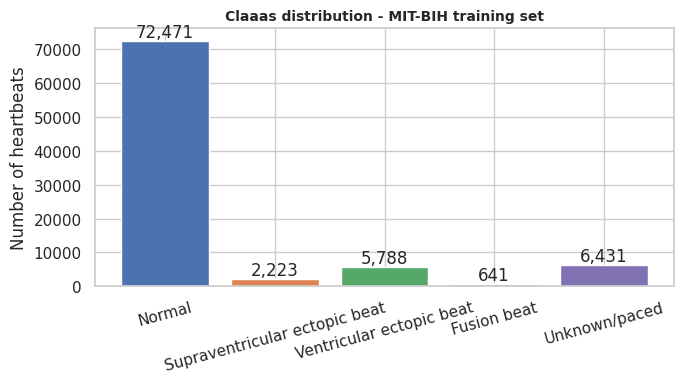

Imbalane ratio (Normal : Ventricular): 12.5 : 1


In [4]:
class_names = {0: "Normal",
               1: "Supraventricular ectopic beat",
               2: "Ventricular ectopic beat",
               3: "Fusion beat",
               4: "Unknown/paced"}

fig, ax = plt.subplots(figsize=(7,4))
counts = train_df[187].value_counts().sort_index()
bars = ax.bar([class_names[i] for i in counts.index], counts.values, color=sns.color_palette("deep", 5))
ax.set_title("Claaas distribution - MIT-BIH training set", fontsize=10, weight="bold")
ax.set_ylabel("Number of heartbeats")
ax.bar_label(bars, fmt="{:,.0f}")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f"Imbalane ratio (Normal : Ventricular): "
      f"{counts[0] / counts[2]:.1f} : 1")

The dataset is heavily imbalanced, Normal beats (0) dominates. This means the *Class_weight = "Balanced"* will be required for fair evaluation metrics.

## **Example waveforms per class**

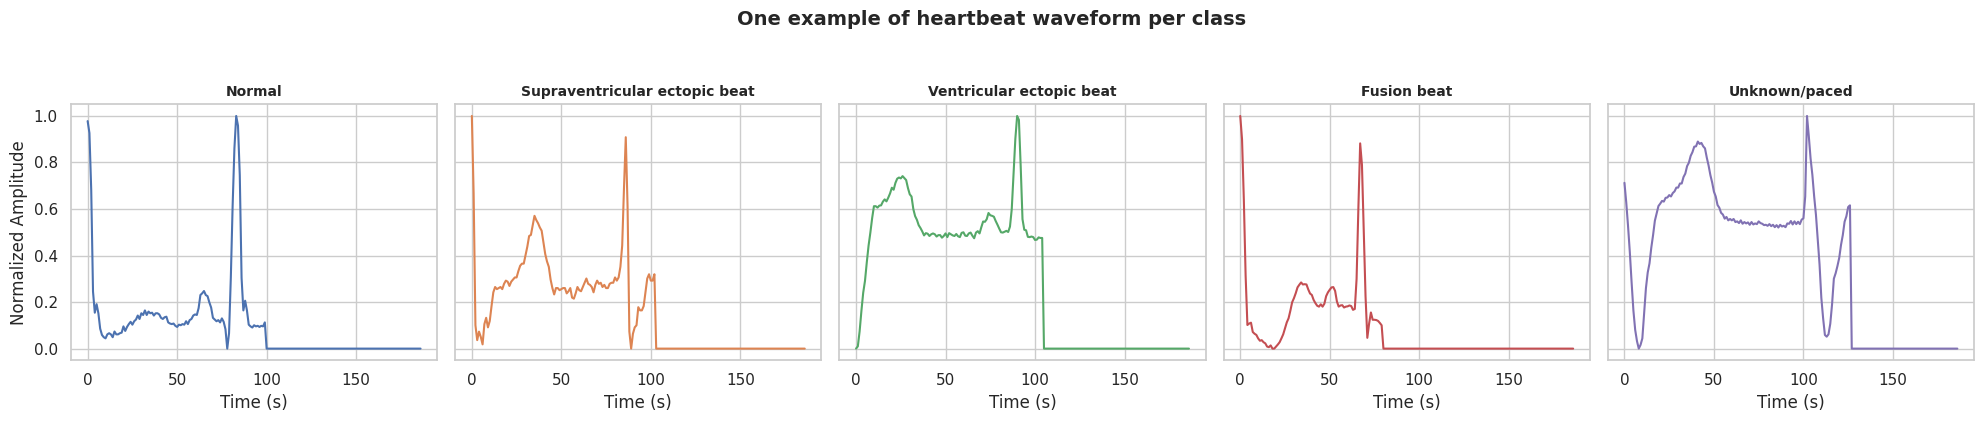

In [5]:
fig, axes = plt.subplots(1,5, figsize=(20,4), sharey=True)

for i, (label, name) in enumerate(class_names.items()):
  sample = train_df[train_df[187]==label].iloc[0, :187]. values
  axes[i].plot(sample, color=sns.color_palette("deep", 5)[i], linewidth=1.5)
  axes[i].set_title(name, fontsize=10, weight="bold")
  axes[i].set_xlabel("Time (s)")
axes[0].set_ylabel("Normalized Amplitude")
fig.suptitle("One example of heartbeat waveform per class", fontsize=14, weight="bold", y=1.05)
plt.tight_layout()
plt.show()

#### **Observations**

Normal heartbeats have clean, sharp spikes and return to the baseline. Venticular ectopic beats are noticeably wider and distorted. These plots show that shape over time is an indciactor that requires a sequential model.

## **Preprocessing**

 **features:** columns 0-186

 **Target:** column 187

Reshaping features to *(samples, 187, 1)*

No scaling needed since the dataset is normalized.

In [6]:
X_train = train_df.iloc[:, :187].values
Y_train = train_df[187].values.astype(int)
X_test = test_df.iloc[:, :187].values
Y_test = test_df[187].values.astype(int)

#Reshaping for sequence models
X_train_seq = X_train.reshape(-1, 187, 1)
X_test_seq = X_test.reshape(-1, 187, 1)

# class weighting
calss_weigth_arr = compute_class_weight(class_weight="balanced",
                                    classes=np.unique(Y_train),
                                    y=Y_train)

class_weights = dict(enumerate(calss_weigth_arr))
print("Class wights:", class_weights)

print("X_train_seq shape:", X_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)


Class wights: {0: np.float64(0.24162492583240192), 1: np.float64(7.877103013945119), 2: np.float64(3.0253628196268143), 3: np.float64(27.317940717628705), 4: np.float64(2.7228735810915876)}
X_train_seq shape: (87554, 187, 1)
X_test_seq shape: (21892, 187, 1)


## **Stratified Split**

In [7]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train_seq, Y_train, test_size=0.1, stratify=Y_train, random_state=42)

## **Building & Training LSTM**

**Architecture**
1. *Two stacked LSTM layers*: the first returns the  full sequence, the second returns only the final hidden state - summary of the full beat.
2. *Dropout*: between layers to reduce overfitting on the majority class.
3. *Dense softmax* for the 5 way classification
4. *Class weights*: to avoid ignoring rare classes

In [8]:
def build_lstm(input_shape=(187,1), n_classes=5):
  model = models.Sequential([
      layers.Input(shape=input_shape),
      layers.LSTM(64, return_sequences=True),
      layers.Dropout(0.3),
      layers.LSTM(32),
      layers.Dropout(0.3),
      layers.Dense(32, activation="relu"),
      layers.Dense(n_classes, activation="softmax")
  ], name="LSTM_classiefier")

  model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"]
  )

  return model

lstm_model = build_lstm()
lstm_model.summary()

#training

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


start = time.time()
lstm_history = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs = 30,
    batch_size=256,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

lstm_train_time = time.time() - start

lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test_seq, Y_test, verbose=1)
lstm_preds = np.argmax(lstm_model.predict(X_test_seq, verbose=0), axis=1)
lstm_f1 = f1_score(Y_test, lstm_preds, average="macro")

print(f"LSTM - test accuracy: {lstm_test_acc:.3f}")
print(f"LSTM - test macro F1 score: {lstm_f1:.3f}")
print(f"Train time: {lstm_train_time:.2f} seconds")

Model: "LSTM_classiefier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 187, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 187, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,533 (119.27 KB)

 Trainable params: 30,533 (119.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.1817 - loss: 1.4194 - val_accuracy: 0.1664 - val_loss: 1.5551
Epoch 2/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.2856 - loss: 1.2357 - val_accuracy: 0.2968 - val_loss: 1.4512
Epoch 3/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.3145 - loss: 1.1898 - val_accuracy: 0.2857 - val_loss: 1.4163
Epoch 4/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.3132 - loss: 1.1539 - val_accuracy: 0.2668 - val_loss: 1.4529
Epoch 5/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.3612 - loss: 1.0971 - val_accuracy: 0.4263 - val_loss: 1.2717
Epoch 6/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.3891 - loss: 1.0696 - val_accuracy: 0.3738 - val_loss: 1.3159
Epoch 7/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4354 - loss: 1.0571 - val_accuracy: 0.3749 - val_loss: 1.3959
Epoch 8/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.4311 - loss: 1.0791 - val_acc

## **Comparison Models**

## **Plain RNN**

In [16]:
def build__simple_rnn(input_shape=(187,1), n_classes=5):
  model_rnn = models.Sequential([
      layers.Input(shape=input_shape),
      layers.SimpleRNN(64, return_sequences=True),
      layers.Dropout(0.3),
      layers.SimpleRNN(32),
      layers.Dropout(0.3),
      layers.Dense(32, activation="relu"),
      layers.Dense(n_classes, activation="softmax")
  ], name="Simple_RNN_Classifier")

  model_rnn.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"]
  )

  return model_rnn

rnn_model = build__simple_rnn()

#training

start = time.time()
rnn_history = rnn_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs = 30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

rnn_train_time = time.time() - start

rnn_test_loss, rnn_test_acc = rnn_model.evaluate(X_test_seq, Y_test, verbose=0)
rnn_preds = np.argmax(rnn_model.predict(X_test_seq, verbose=0), axis=1)
rnn_f1 = f1_score(Y_test, rnn_preds, average="macro")

print(f"RNN - test accuracy: {rnn_test_acc:.3f}")
print(f"RNN - test macro F1 score: {rnn_f1:.3f}")
print(f"Train time: {rnn_train_time:.2f} seconds")

Epoch 1/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.2266 - loss: 1.6343 - val_accuracy: 0.6672 - val_loss: 1.5629
Epoch 2/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.3202 - loss: 1.6130 - val_accuracy: 0.0432 - val_loss: 1.6126
Epoch 3/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.1952 - loss: 1.5947 - val_accuracy: 0.0847 - val_loss: 1.5948
Epoch 4/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.1594 - loss: 1.5794 - val_accuracy: 0.0188 - val_loss: 1.6261
Epoch 5/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.0994 - loss: 1.5612 - val_accuracy: 0.0783 - val_loss: 1.6022
RNN - test accuracy: 0.670
RNN - test macro F1 score: 0.198
Train time: 56.47 seconds


In [10]:
print(type(X_test), getattr(X_test, "shape", "NO SHAPE"))
print(type(Y_test), getattr(Y_test, "shape", "NO SHAPE"))

<class 'numpy.ndarray'> (21892, 187)
<class 'numpy.ndarray'> (21892,)


## **Non-Sequential MLP baseline**

In [11]:
X_tr_flat, X_val_flat, y_tr_flat, y_val_flat = train_test_split(
    X_train, Y_train, test_size=0.1, stratify=Y_train, random_state=42
)


def build_mlp(input_dim =187, n_classes=5):
  model_mlp = models.Sequential([
      layers.Input(shape=(input_dim,)),
      layers.Dense(64, activation="relu"),
      layers.Dropout(0.3),
      layers.Dense(32, activation="relu"),
      layers.Dropout(0.3),
      layers.Dense(n_classes, activation="softmax")
  ], name="MLP_baseline")

  model_mlp.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"]
  )

  return model_mlp

mlp_model = build_mlp()

#training

start = time.time()
mlp_history = mlp_model.fit(
    X_tr_flat, y_tr_flat,
    validation_data=(X_val_flat, y_val_flat),
    epochs = 30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

mlp_train_time = time.time() - start

mlp_test_loss, mlp_test_acc = mlp_model.evaluate(X_test, Y_test, verbose=0)
mlp_preds = np.argmax(mlp_model.predict(X_test, verbose=0), axis=1)
mlp_f1 = f1_score(Y_test, mlp_preds, average="macro")

print(f"RNN - test accuracy: {mlp_test_acc:.3f}")
print(f"RNN - test macro F1 score: {mlp_f1:.3f}")
print(f"Train time: {mlp_train_time:.2f} seconds")

Epoch 1/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4728 - loss: 1.0792 - val_accuracy: 0.5077 - val_loss: 1.1072
Epoch 2/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5747 - loss: 0.7643 - val_accuracy: 0.6205 - val_loss: 0.9297
Epoch 3/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6365 - loss: 0.6752 - val_accuracy: 0.6673 - val_loss: 0.8623
Epoch 4/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6746 - loss: 0.6300 - val_accuracy: 0.7190 - val_loss: 0.7581
Epoch 5/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7079 - loss: 0.5813 - val_accuracy: 0.7344 - val_loss: 0.7733
Epoch 6/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7253 - loss: 0.5527 - val_accuracy: 0.7571 - val_loss: 0.7122
Epoch 7/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7388 - loss: 0.5323 - val_accuracy: 0.7893 - val_loss: 0.6530
Epoch 8/30
308/308 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7545 - loss: 0.5159 - val_accuracy: 0

In [17]:
print("RNN prediction distribution", np.bincount(rnn_preds,minlength=5))
print("True distribution:", np.bincount(Y_test, minlength=5))

RNN prediction distribution [18090    68    52  3603    79]
True distribution: [18118   556  1448   162  1608]


## **Results before Stratified Split**

The first pass used validation_split=0.1 and an unshuffled dataset

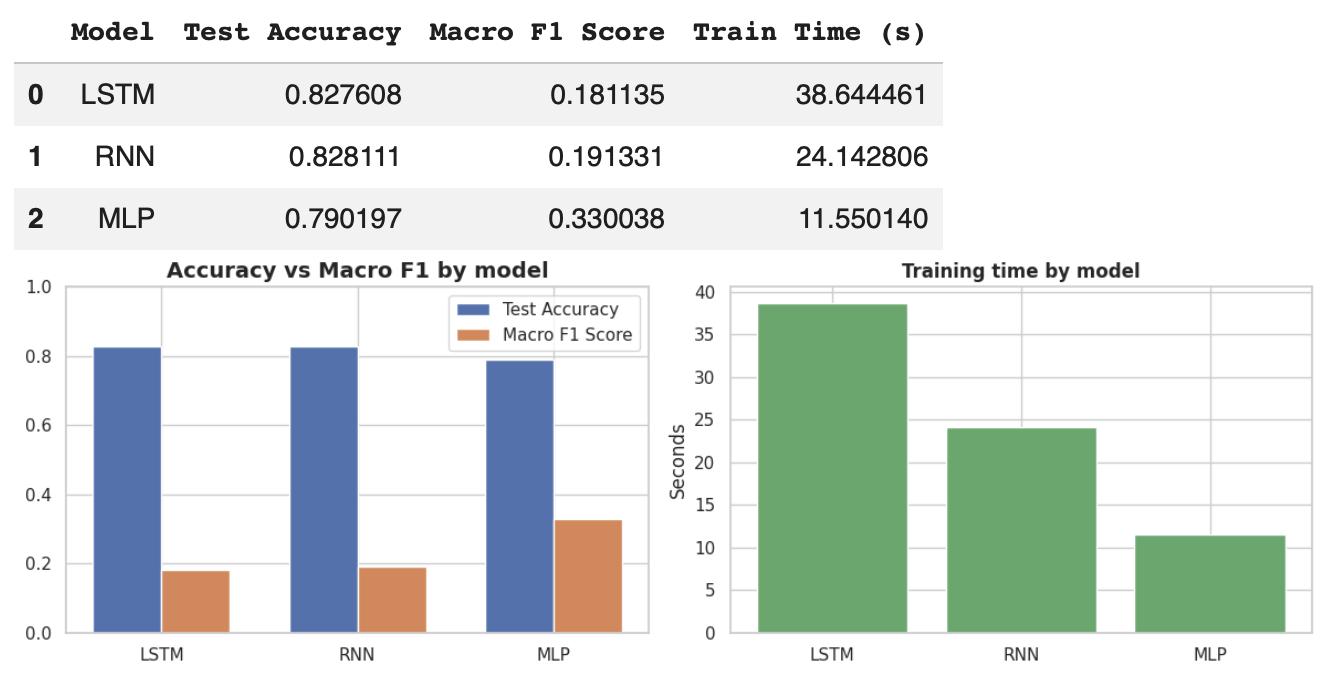

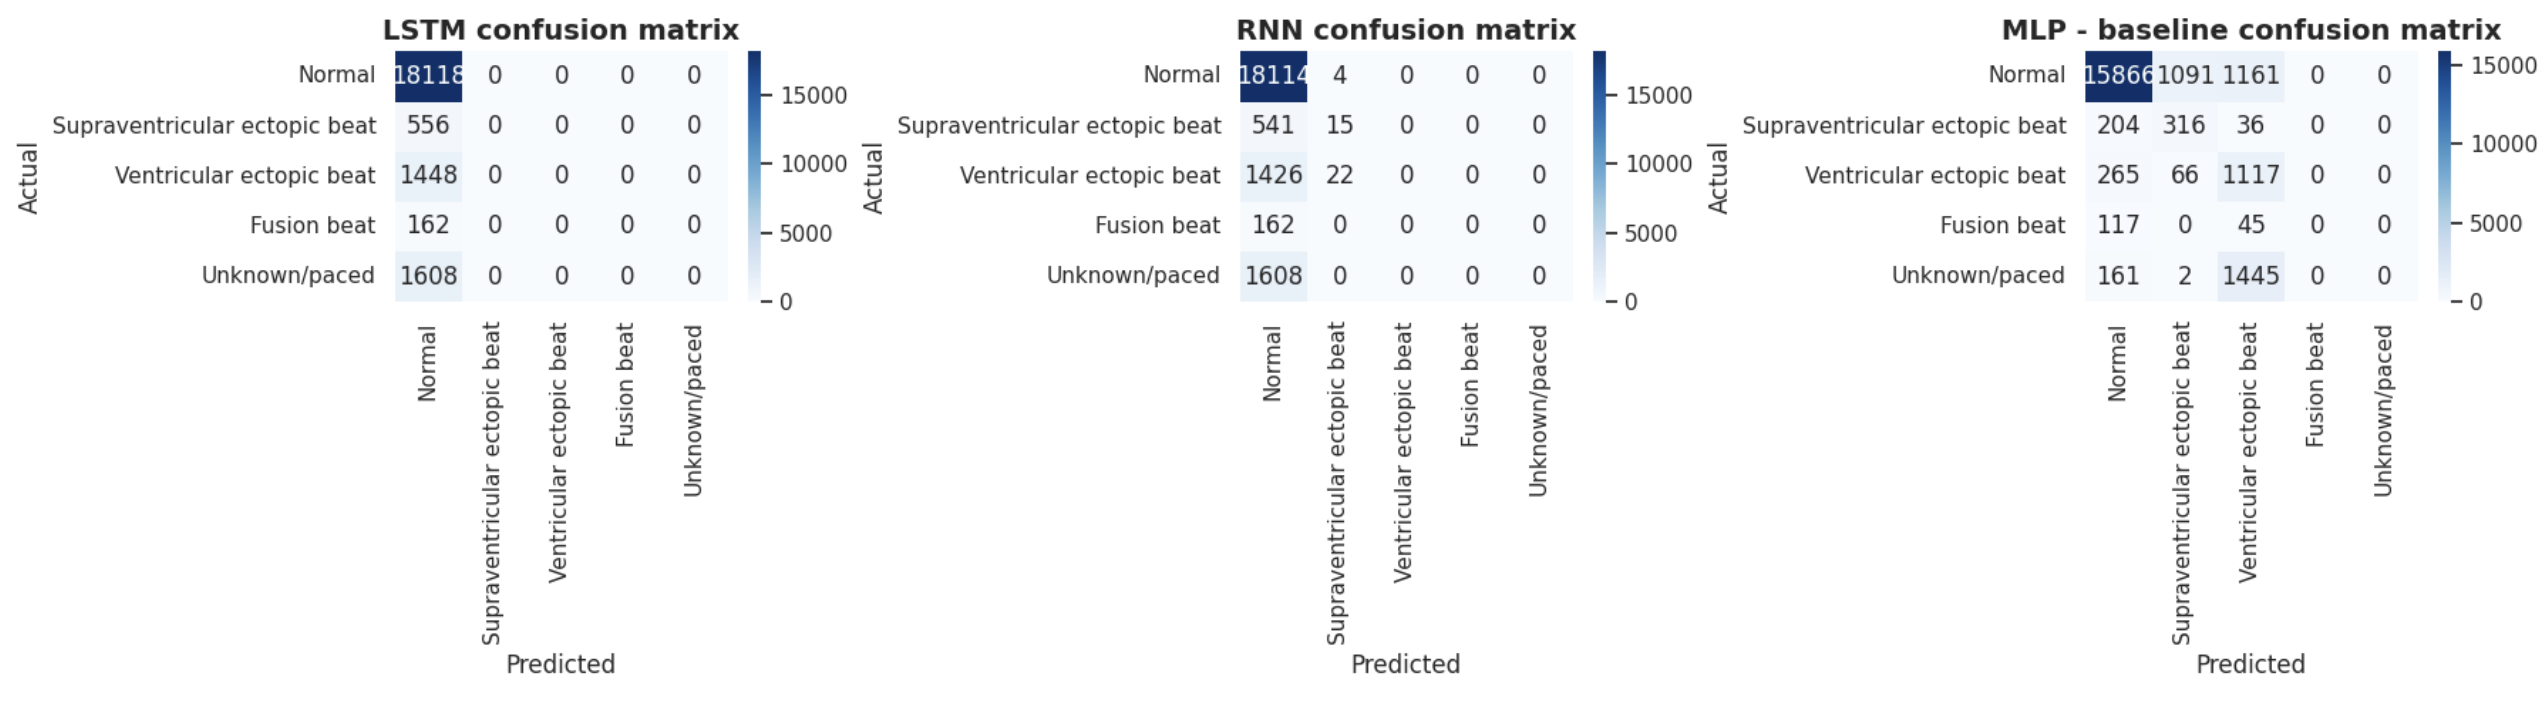

Imbalance in the dataset created a trap; the recurrent model's slower path to learning minority-class signal, combined with a unequally represented dataset in the validation split, is why the sequential models fell into it. In other words, the sequential model's accuracy isscores high fake results due to predicting the majority class while oversseing the minor ones, and that has a small impact on the accracy. MLP was not affected by the unstratified split.

## **Fix**
alll three models were rerun with *train_test_split*, *patience=5*, and the MLP baseline data was flattened into a 1D array.

## **Bar Chart Comparison**

,Model,Test Accuracy,Macro F1 Score,Train Time (s)
0,LSTM,0.422437,0.287075,71.584431
1,RNN,0.669651,0.198138,56.472388
2,MLP,0.839119,0.629478,33.751162


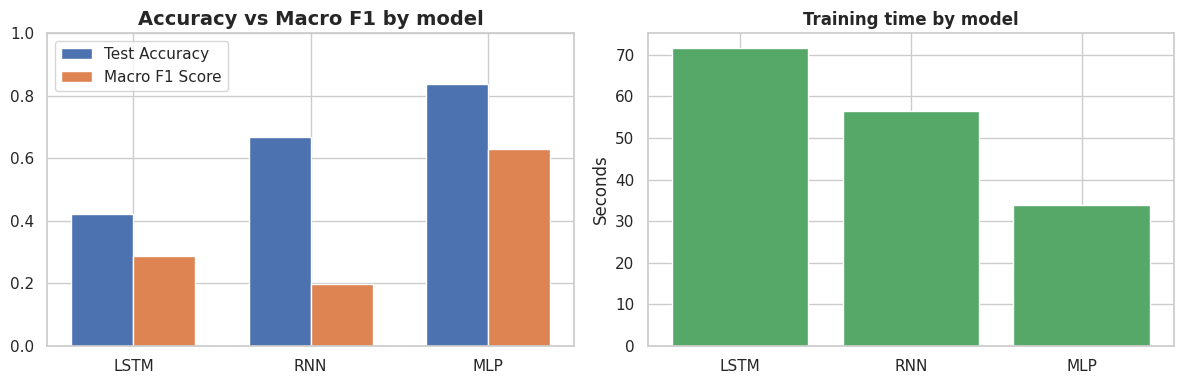

In [18]:
results = pd.DataFrame({
    "Model": ["LSTM", "RNN", "MLP"],
    "Test Accuracy": [lstm_test_acc, rnn_test_acc, mlp_test_acc],
    "Macro F1 Score": [lstm_f1, rnn_f1, mlp_f1],
    "Train Time (s)": [lstm_train_time, rnn_train_time, mlp_train_time]
})
display(results)

fig, axes = plt.subplots(1,2, figsize=(12,4))

x = np.arange(len(results))
width = 0.35

axes[0].bar(x, results["Test Accuracy"], width, label="Test Accuracy", color="#4C72B0")
axes[0].bar(x + width, results["Macro F1 Score"], width, label="Macro F1 Score", color="#DD8452")
axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(results["Model"])
axes[0].set_ylim(0,1)
axes[0].set_title("Accuracy vs Macro F1 by model", fontsize=14, weight="bold")
axes[0].legend()

axes[1].bar(results["Model"], results["Train Time (s)"], color="#55A868")
axes[1].set_title("Training time by model", weight="bold")
axes[1].set_ylabel("Seconds")

plt.tight_layout()
plt.show()


The bar charts above suggest that the MLP model is the best model among the 3, scoring the highest accuracy and F1 scores. MLP correctly predicts over 80% (around 83%) of the record's classes, achieving a macro F1 score of around 0.63.

In contrast, the LSTM shows very low test accuracy (around 42%) and a macro F1 score of under 0.30. The RNN achieves around 66% test accuracy, but a macro F1 score below 0.20 indicates that it fails on smaller classes or severely misclassifies them.

In terms of training speed, the MLP model is the fastest, taking roughly 34 seconds, compared to the RNN (~56 seconds) and the LSTM, which took the longest at over 70 seconds.

## **Loss Curves**

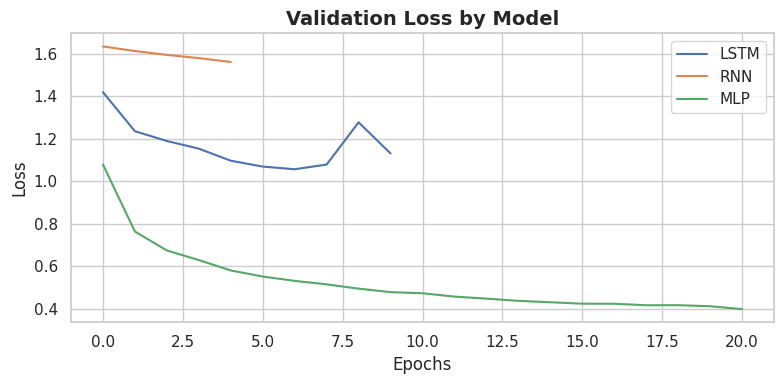

In [19]:
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(lstm_history.history["loss"], label="LSTM")
ax.plot(rnn_history.history["loss"], label="RNN")
ax.plot(mlp_history.history["loss"], label="MLP")
ax.set_title("Validation Loss by Model", fontsize=14, weight="bold")
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

**Observations**

RNN stopped at epoch 4, and LSTM stopped at epoch 9, while MLP completed 20 epochs.

MLP showed a dramatic drop in loss initially followed by steady improvement throughout the epochs, whereas RNN showed minimal loss reduction before stopping early, and LSTM experienced a slight drop followed by a spike and eventual termination.

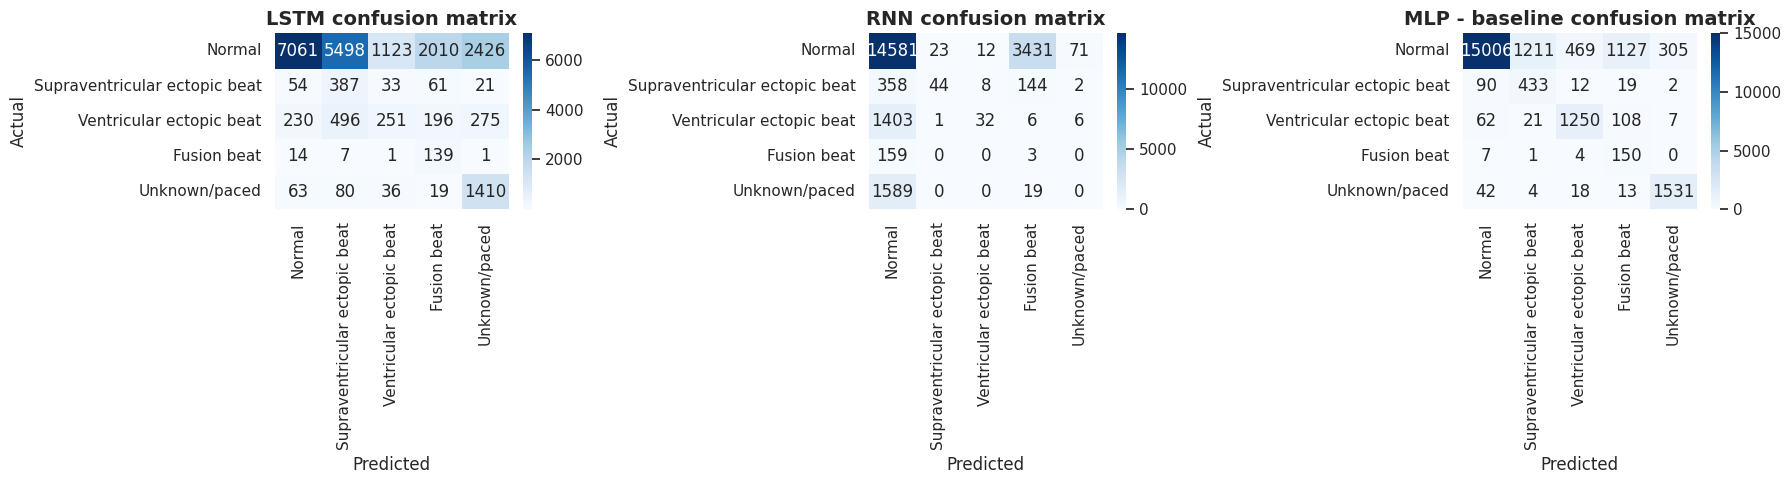

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, preds, name in zip(
    axes, [lstm_preds, rnn_preds, mlp_preds], ["LSTM", "RNN", "MLP - baseline"]
):

    cm = confusion_matrix(Y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=class_names.values(), yticklabels=class_names.values())
    ax.set_title(f"{name} confusion matrix", fontsize=14, weight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

**LSTM Matrix**
Underperforming overall. While it predicts 7,061 Normal beats correctly, it exhibits significant confusion across categories, misclassifying 5,498 Normal beats as Supraventricular ectopic beats and showing high off-diagonal values across multiple classes.

**RNN Matrix**
Severely underperforming due to class collapse. Misclassification is heavily biased toward predicting almost all instances as either Normal (14,581) or Fusion beat (3,431). RNNs struggle with sequential patterns in this setup, completely failing to identify minority classes like Ventricular ectopic beat, Fusion beat, and Unknown/paced.

**MLP Matrix**
Best overall performance. Diagonal values are noticeably higher than off-diagonal values compared to the RNN and LSTM. It successfully captures the majority of both the primary Normal class (15,006 correctly predicted) and minority classes accurately (e.g., 1,250 Ventricular ectopic beats and 1,531 Unknown/paced beats), resulting in superior precision and recall across all categories.

## **Final Results**

**Results**
| Model | Test Accuracy | Macro F1 |
|---|---|---|
|**LSTM** | 0.42| 0.28 |
| **RNN** | 0.66 | 0.19 |
| **MLP** | 0.83 | 0.63 |

The **MLP achieved the best macro F1 and test accuracy**, beating both the LSTM and the plain RNN. This indicates that the non-sequential dense baseline was better suited for capturing distinct shape-based thresholds across the 187 time-series features in this specific setup without suffering from sequence-length training instabilities.

#### **The RNN & LSTM Collapse**

**RNN**: Showed severe class collapse and underperformed with a macro F1 of 0.19. It predicted almost all instances as either Normal (14,581) or Fusion beat (3,431), while completely missing minority classes like Ventricular ectopic beat (32 correct), Supraventricular ectopic beat (44 correct), and Unknown/paced (0 correct). This failure to propagate long-range temporal dependencies is consistent with the vanishing gradient problem in vanilla RNNs during early training steps.

**LSTM**: Stopped early at epoch 9 due to loss instabilities (spiking before termination). Despite using gated units, it suffered from widespread cross-class confusion—misclassifying 5,498 Normal beats as Supraventricular ectopic beats—leading to a low test accuracy of 0.42 and macro F1 of 0.28.



#### **Why is Macro F1 important for this dataset?**

Macro F1 is the sum of the F1 scores for all classes divided by their count. It gives equal weight to every class which helps recognising minority classes. It is necessary for this datset to help explose poor performance on rare classes.

## **Key Findings**

* Non-sequential baseline superior for this setup: The MLP outperformed the recurrent models in both overall test accuracy (0.83) and Macro F1 (0.63). This shows that a strong class-distinguishing signal is present directly across the static features without requiring full sequence modeling.
* Recurrent model instabilities: The plain RNN suffered from class collapse, achieving a low Macro F1 (0.19) due to vanishing gradients on 187-time-step sequences. While LSTM avoided total class collapse, loss spikes led to early termination at epoch 9, causing severe cross-class confusion and lower balanced performance (0.28 Macro F1).
* Importance of balanced metrics: Accuracy alone proved to be a highly misleading metric for this dataset—the plain RNN achieved 66% test accuracy despite almost entirely missing minority classes like Ventricular ectopic and Unknown beats.
* Diagnostic value of confusion matrices: Macro F1 was essential for capturing class-wise imbalances, and confusion matrices were necessary to reveal specific failure modes, such as the LSTM misclassifying 5,498 Normal beats as Supraventricular ectopic beats.